In [2]:
import matplotlib.pyplot as plt
import numpy as np
import itertools

My reasoning: Numbers that can be written as the sum of powers of their digits will likely be very rare as the numbers get larger: Consider the example of 1634 and fourth powers; this means that

$$
    1\times 10^3 + 6\times 10^2 + 3\times 10^1 + 4\times 10^0 = 1^4+6^4+3^4+4^4.
$$

Having solutions for such equations seems more and more impossible as we move into five- or six-digit numbers, since $10^5$ and $10^6$ are very large indeed.

Writing a function that calculates the sum of powers of the digits of a number is easy enough:

In [6]:
def digitpower(n: int, exp: int = 5) -> int:
    if int(n) != n: raise ValueError(f"n must be integer; received {n}")
    return sum([digit ** exp for digit in map(int, str(n))])

But now - if I were to solve problem 30 a little more thoughtfully than just applying brute force - I'd have to ask myself: Up to which number $N$ should I check for numbers that are equal to their digit-powers?

Let's make a guess by looking at the digit-powers of randomly generated numbers.

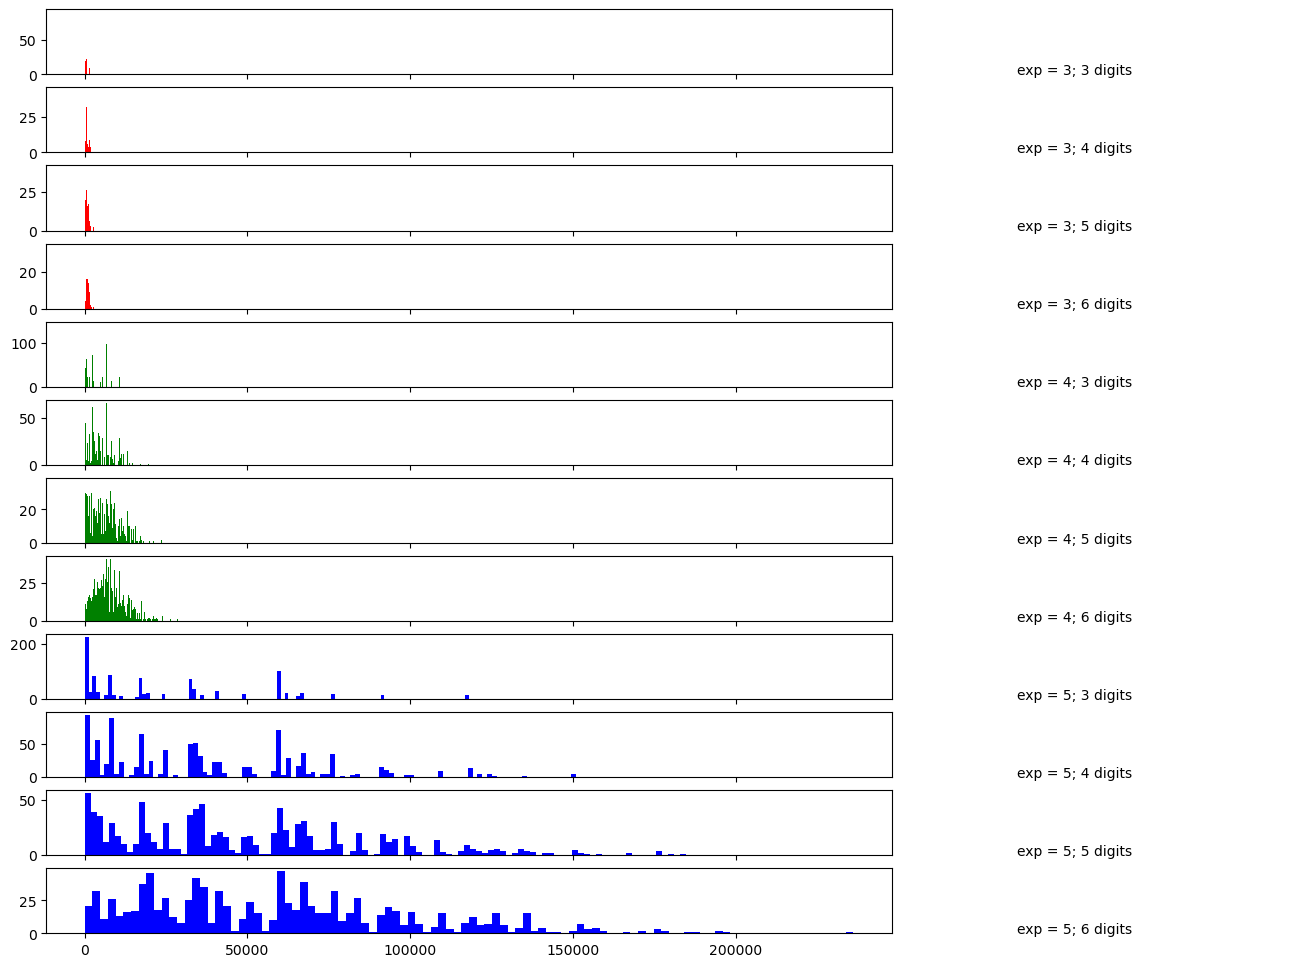

In [19]:
fig, ax = plt.subplots(
    nrows=12,
    ncols=2,
    sharex=True,
    figsize=(16, 12),
    width_ratios=(3, 1),
)

n_bins = 100
n_samples = 1000

for i, ((exp, col), ndigits, ) in enumerate(itertools.product(
    zip((3, 4, 5), ("red", "green", "blue")),
    (3, 4, 5, 6)
)):
    nums = np.random.randint(low=0, high=10 ** (ndigits - 1) + 1, size=n_samples)
    digitpowers = [digitpower(n, exp) for n in nums]
    ax[i, 0].hist(digitpowers, bins=n_bins, color=col)
    ax[i, 1].set_axis_off()
    ax[i, 1].text(0, 0, f"exp = {exp}; {ndigits} digits")

For six digit numbers and the exponent $5$, the largest digit power sum seems to lie around $250000$ - which is also a six-digit number. So it is conceivable that there are matches with six digits. But I'll only check up to $300000$, which I expect to be sufficient.

In [22]:
exp = 5
matches = []
for n in range(2, 300000):
    if n == digitpower(n, exp): matches.append(n)

print(f"There are {len(matches)} numbers that are equal to their digit power sum with exponent {exp}:", matches)
print(f"Their sum is {sum(matches)}.")

There are 6 numbers that are equal to their digit power sum with exponent 5: [4150, 4151, 54748, 92727, 93084, 194979]
Their sum is 443839.
